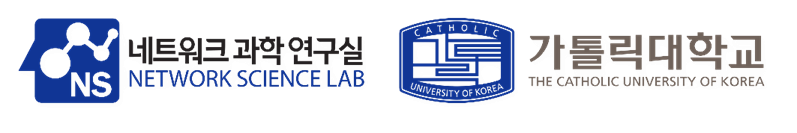

<h1><center><b>💻 Assignment 2:</b> </br> Graph Representation 🚀</center></h1>

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Mining-Spring-2026/blob/main/W2/Assignment_2_Solutions.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Scenario 1: City Delivery Network Design 🏙️
You are a data analyst at a logistics company. Each node is a warehouse (A to L), and each directed edge is a delivery route.

### **Task 1** 🎯
Create a **weighted, directed graph** with the following conditions:
- Number of nodes: **12**
- Number of edges: **20**
- Edge weight: random float in **[2, 15]** (delivery time or cost)
- Node labels: uppercase letters **A to L**
- You may use **NetworkX** or your own graph class

### Expected output ✅
- A graph visualization with node labels and edge weights

💡 *Tip: Think of edge weights as travel cost or delivery time.*

🔥 *Challenge yourself: can you make your visualization easy for managers to read?*

In [7]:
# If needed:
# !pip install networkx pandas numpy matplotlib openpyxl

import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Reproducibility
random.seed(42)
np.random.seed(42)

Nodes: 12 | Edges: 20
Sample routes: [('A', 'B', 3.26), ('A', 'E', 13.02), ('A', 'I', 9.85), ('B', 'G', 12.49), ('B', 'J', 11.49)]


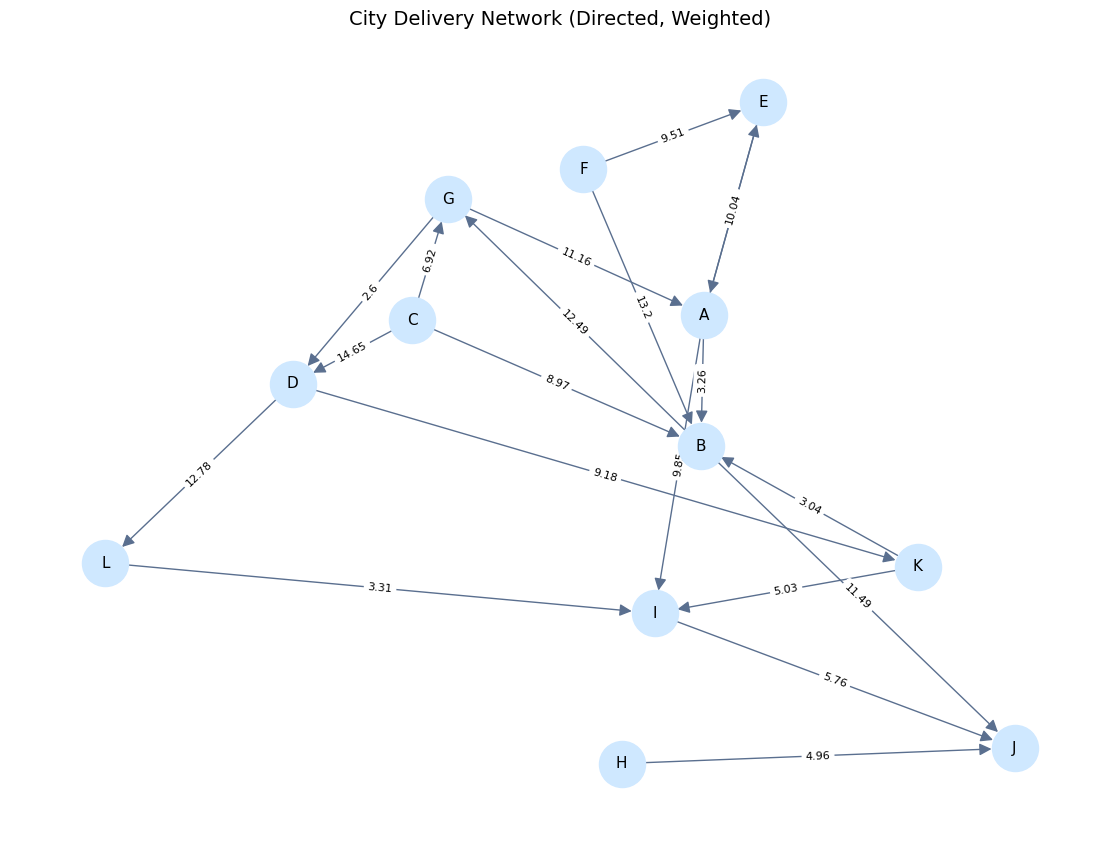

In [8]:
# Scenario 1: Build a city delivery network (directed + weighted)
num_nodes = 12
num_edges = 20
node_labels = [chr(65 + i) for i in range(num_nodes)]  # A..L

G = nx.DiGraph()
G.add_nodes_from(node_labels)

# Generate unique directed edges (no self-loops)
edge_set = set()
while len(edge_set) < num_edges:
    source, target = random.sample(node_labels, 2)
    edge_set.add((source, target))

# Attach random route cost/time
weighted_edges = []
for source, target in sorted(edge_set):
    weight = round(random.uniform(2, 15), 2)
    weighted_edges.append((source, target, weight))

G.add_weighted_edges_from(weighted_edges)

print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
print("Sample routes:", weighted_edges[:5])

# Visualize the network
plt.figure(figsize=(11, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="#CFE8FF",
    edge_color="#5A6F8F",
    node_size=1100,
    arrowsize=18,
    font_size=11,
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("City Delivery Network (Directed, Weighted)", fontsize=14)
plt.axis("off")
plt.show()

## Scenario 2: Network Operations Dashboard 📊
Using the graph from Scenario 1, support operations managers with key analytics.

### **Task 2** 🧠
1. Display both **sparse** and **dense** adjacency matrices.
2. Display the **adjacency list**.
3. Compute the graph **diameter**.
4. For a user-selected warehouse, print:
   - Number of incoming routes (in-degree)
   - Number of outgoing routes (out-degree)
5. Write a function to print the **shortest path** between two warehouses.
6. Write functions to print all **in-edges** and **out-edges** of a warehouse.

### Expected output ✅
A concise report-style output that can be reused in an operations notebook.


In [9]:
# Scenario 2: Operations analytics on the delivery network

# 1) Sparse adjacency matrix
A_sparse = nx.adjacency_matrix(G, nodelist=node_labels, weight="weight")
print("Sparse adjacency matrix:")
print(A_sparse)

# 2) Dense adjacency matrix (DataFrame for readability)
A_dense = pd.DataFrame(
    A_sparse.toarray(),
    index=node_labels,
    columns=node_labels,
)
print("\nDense adjacency matrix:")
display(A_dense)

# 3) Adjacency list
print("Adjacency list (outgoing routes):")
for node in node_labels:
    neighbors = list(G.successors(node))
    print(f"{node}: {neighbors}")

# 4) Graph diameter
# For directed weighted graphs, diameter is often computed on a connected undirected view.
G_und = G.to_undirected()
if nx.is_connected(G_und):
    diameter = nx.diameter(G_und)
    print(f"\nGraph diameter (undirected view): {diameter}")
else:
    largest_cc = max(nx.connected_components(G_und), key=len)
    subgraph = G_und.subgraph(largest_cc)
    diameter = nx.diameter(subgraph)
    print("\nGraph is disconnected in undirected view.")
    print(f"Diameter of largest connected component: {diameter}")

# 5) In-degree / out-degree for a selected node
selected_node = "B"  # replace with input("Enter node A-L: ").strip().upper() if needed
print(f"\nSelected warehouse: {selected_node}")
print(f"In-degree:  {G.in_degree(selected_node)}")
print(f"Out-degree: {G.out_degree(selected_node)}")

# 6) Shortest path between two nodes (weighted)
def shortest_path_report(graph, source, target):
    try:
        path = nx.shortest_path(graph, source=source, target=target, weight="weight", method="dijkstra")
        total_cost = nx.shortest_path_length(graph, source=source, target=target, weight="weight", method="dijkstra")
        print(f"\nShortest path {source} -> {target}: {' -> '.join(path)}")
        print(f"Total cost: {total_cost:.2f}")
        return path, total_cost
    except nx.NetworkXNoPath:
        print(f"\nNo path exists from {source} to {target}.")
        return None, None

# 7) Functions to print all in-edges / out-edges
def print_in_edges(graph, node):
    in_edges = list(graph.in_edges(node, data=True))
    print(f"\nIn-edges of {node}:")
    for u, v, data in in_edges:
        print(f"{u} -> {v}, weight={data.get('weight')}")


def print_out_edges(graph, node):
    out_edges = list(graph.out_edges(node, data=True))
    print(f"\nOut-edges of {node}:")
    for u, v, data in out_edges:
        print(f"{u} -> {v}, weight={data.get('weight')}")


_ = shortest_path_report(G, "A", "B")
print_in_edges(G, selected_node)
print_out_edges(G, selected_node)

Sparse adjacency matrix:
<Compressed Sparse Row sparse array of dtype 'float64'
	with 20 stored elements and shape (12, 12)>
  Coords	Values
  (0, 1)	3.26
  (0, 4)	13.02
  (0, 8)	9.85
  (1, 6)	12.49
  (1, 9)	11.49
  (2, 1)	8.97
  (2, 3)	14.65
  (2, 6)	6.92
  (3, 10)	9.18
  (3, 11)	12.78
  (4, 0)	10.04
  (5, 1)	13.2
  (5, 4)	9.51
  (6, 0)	11.16
  (6, 3)	2.6
  (7, 9)	4.96
  (8, 9)	5.76
  (10, 1)	3.04
  (10, 8)	5.03
  (11, 8)	3.31

Dense adjacency matrix:


,A,B,C,D,E,F,G,H,I,J,K,L
A,0.00,3.26,0.0,0.00,13.02,0.0,0.00,0.0,9.85,0.00,0.00,0.00
B,0.00,0.00,0.0,0.00,0.00,0.0,12.49,0.0,0.00,11.49,0.00,0.00
C,0.00,8.97,0.0,14.65,0.00,0.0,6.92,0.0,0.00,0.00,0.00,0.00
D,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,9.18,12.78
E,10.04,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
F,0.00,13.20,0.0,0.00,9.51,0.0,0.00,0.0,0.00,0.00,0.00,0.00
G,11.16,0.00,0.0,2.60,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
H,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.00,4.96,0.00,0.00
I,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.00,5.76,0.00,0.00
J,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00


Adjacency list (outgoing routes):
A: ['B', 'E', 'I']
B: ['G', 'J']
C: ['B', 'D', 'G']
D: ['K', 'L']
E: ['A']
F: ['B', 'E']
G: ['A', 'D']
H: ['J']
I: ['J']
J: []
K: ['B', 'I']
L: ['I']

Graph diameter (undirected view): 4

Selected warehouse: B
In-degree:  4
Out-degree: 2

Shortest path A -> B: A -> B
Total cost: 3.26

In-edges of B:
A -> B, weight=3.26
C -> B, weight=8.97
F -> B, weight=13.2
K -> B, weight=3.04

Out-edges of B:
B -> G, weight=12.49
B -> J, weight=11.49


## Scenario 3: Import Route Data and Export Adjacency Matrix 📁
Your team receives route data from a partner system and needs a clean matrix for reporting.

### **Task 3** 🛠️
Write a program to:
- Read an edge-list file (`./data/edges.txt`) of an **undirected weighted graph**
- Build the graph
- Convert it to a **dense adjacency matrix**
- Save the matrix to an output file

### 📥 Input Format
Each line in the edge-list file represents one undirected weighted edge:

`Node1 Node2 Weight`

- `Node1`, `Node2`: integer node IDs  
- `Weight`: numeric edge weight

---

### 🧾 Example Edge List

| Node1 | Node2 | Weight |
|------:|------:|-------:|
| 0 | 1 | 3 |
| 0 | 3 | 5 |
| 0 | 6 | 2 |
| 1 | 4 | 4 |
| 1 | 7 | 6 |
| 2 | 5 | 8 |
| 2 | 8 | 3 |
| 3 | 9 | 7 |
| 4 | 10 | 2 |

---


### Output ✅
A file containing the dense adjacency matrix of the graph.



In [10]:
# install openpyxl if needed for Excel export
!pip install openpyxl

In [11]:
# Scenario 3: Load partner route file and export dense adjacency matrix
edge_file = "data/edges.txt"
output_excel = "data/adjacency.xlsx"

edges = []
with open(edge_file, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 3:
            continue
        try:
            u, v, w = int(parts[0]), int(parts[1]), float(parts[2])
            edges.append((u, v, w))
        except ValueError:
            continue

UG = nx.Graph()
UG.add_weighted_edges_from(edges)

adj_df = nx.to_pandas_adjacency(UG, weight="weight")
adj_df.to_excel(output_excel, sheet_name="adjacency", index=True)

print(f"Loaded edges: {len(edges)}")
print(f"Nodes: {UG.number_of_nodes()} | Edges: {UG.number_of_edges()}")
print(f"Dense adjacency matrix exported to: {output_excel}")

display(adj_df.head())

Loaded edges: 9
Nodes: 11 | Edges: 9
Dense adjacency matrix exported to: data/adjacency.xlsx


,0,1,3,6,4,7,2,5,8,9,10
0,0.0,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.0,0.0,0.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,0.0
3,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0
6,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


<h3><center><b>💻🎉 CONGRATULATIONS! 🎉 </b> </center></h1>
<h4><center>You have finished your exercise! 🌟 Keep up the good work!</center></h2>